In [1]:
library(Seurat)
library(ggplot2)
library(dplyr)
library(ggplot2)
library(ggridges)
library(RColorBrewer)
library(scales)
library(stringr)

Attaching SeuratObject


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [5]:
counts <- readRDS("./pseudobulk_counts2_ann2.RDS")
meta <- readRDS("./pseudobulk_meta_ann2.RDS")

In [ ]:
mer <- merge(as.data.frame(t(as.data.frame(sp@assays$RNA@data))),meta,all = TRUE,by = 0)
rownames(mer) <- mer$Row.names
mer <- mer[,-1]
mer1 <- mer[which(mer$sample_filter!="filter"),]
head(mer1)

In [7]:
library(reshape2)

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


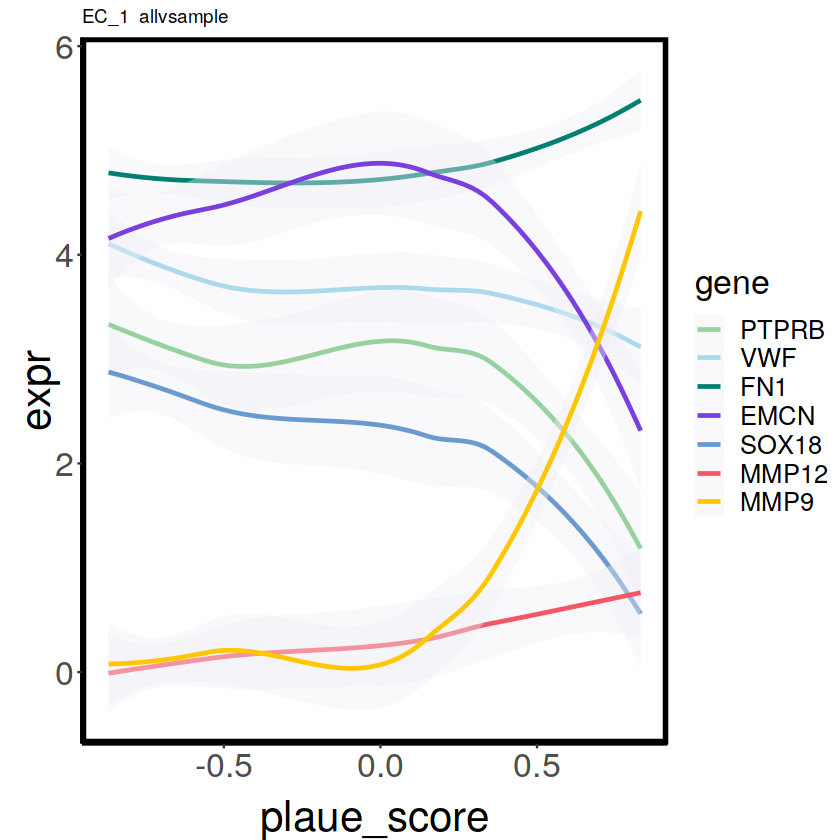

`geom_smooth()` using formula = 'y ~ x'


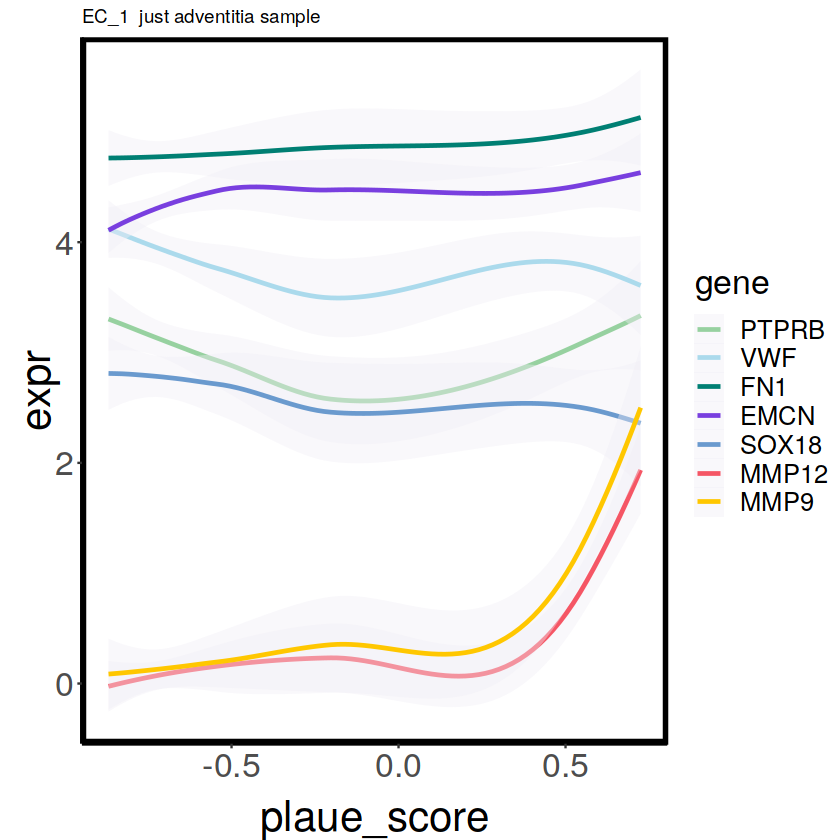

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


png 
  2

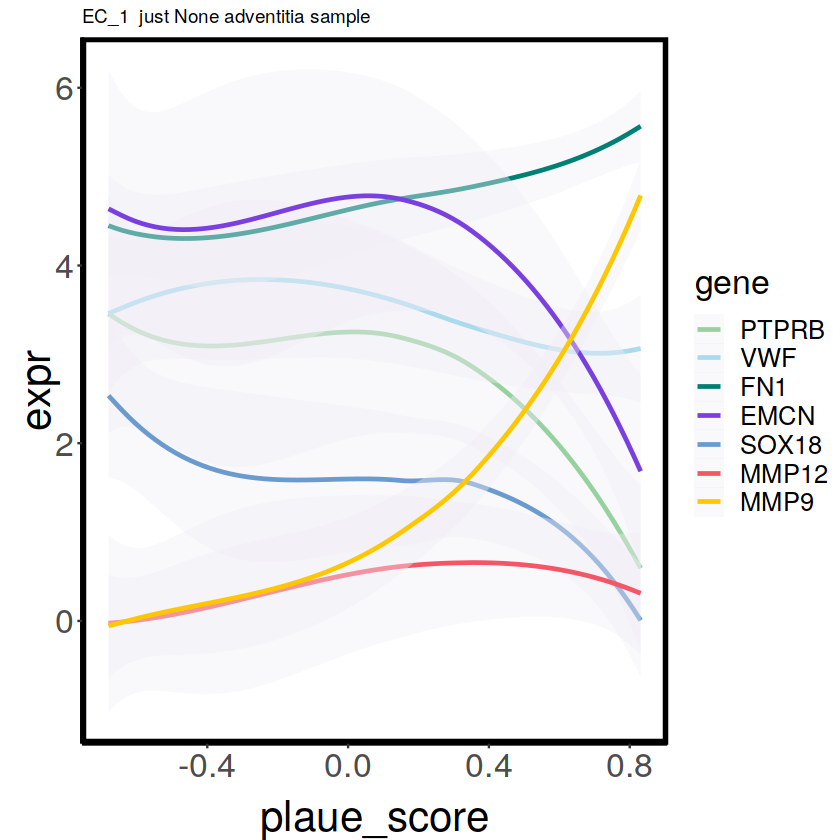

In [12]:
m1 <- subset(mer1,subset = ann2%in%c("EC_1"))
gene<-c("PTPRB","VWF","FN1","EMCN","SOX18","MMP12","MMP9")
m1 <- subset(m1,select = c('score_gsva','score_ssgsea','score_addmodulescore',gene))
m2 <- melt(m1,id.vars = c('score_gsva','score_ssgsea','score_addmodulescore'))
colnames(m2)<- c('score_gsva','score_ssgsea','score_addmodulescore',"gene","exp")
p1 <- ggplot(m2,aes(x=score_gsva,y = exp,color=gene))+theme_classic ()+
scale_color_manual(values = colorRampPalette(c("#97D1A0","#ABDAEC","#007F73","#793FDF","#6A9ACE","#F55665FF","#FFC700"))(7))+geom_smooth(method = "loess",span=1,se = TRUE,level=0.9,fill='#f1eef6')+
labs(x="plaue_score",y="expr")+theme(axis.text = element_text (size = 20))+
    theme(axis.title.x=element_text(vjust=0, size=25,face = "plain"))+
    theme(axis.title.y=element_text(vjust=0, size=25,face = "plain"))+
    theme(plot.title = element_text(size = 25, face = "bold"))+
    theme(axis.line = element_line(color = "black",linewidth = 0.8))+
    theme(legend.title = element_text(size=20),
          legend.text = element_text(size=15))+
theme(panel.border = element_rect(color = "black", fill = NA, linewidth = 2))+labs(subtitle = paste0("EC_1  allvsample"))
p1
m1 <- subset(mer1,subset = ann2%in%c("EC_1")&mer1$adventitia!="none")
m1 <- subset(m1,select = c('score_gsva','score_ssgsea','score_addmodulescore',gene))
m2 <- melt(m1,id.vars = c('score_gsva','score_ssgsea','score_addmodulescore'))
colnames(m2)<- c('score_gsva','score_ssgsea','score_addmodulescore',"gene","exp")
p2 <- ggplot(m2,aes(x=score_gsva,y = exp,color=gene))+theme_classic ()+
scale_color_manual(values = colorRampPalette(c("#97D1A0","#ABDAEC","#007F73","#793FDF","#6A9ACE","#F55665FF","#FFC700"))(7))+geom_smooth(method = "loess",span=1,se = TRUE,level=0.9,fill='#f1eef6')+
labs(x="plaue_score",y="expr")+theme(axis.text = element_text (size = 20))+
    theme(axis.title.x=element_text(vjust=0, size=25,face = "plain"))+
    theme(axis.title.y=element_text(vjust=0, size=25,face = "plain"))+
    theme(plot.title = element_text(size = 25, face = "bold"))+
    theme(axis.line = element_line(color = "black",linewidth = 0.8))+
    theme(legend.title = element_text(size=20),
          legend.text = element_text(size=15))+
theme(panel.border = element_rect(color = "black", fill = NA, linewidth = 2))+labs(subtitle = paste0("EC_1  just adventitia sample"))
p2
m1 <- subset(mer1,subset = ann2%in%c("EC_1")&mer1$adventitia=="none")
m1 <- subset(m1,select = c('score_gsva','score_ssgsea','score_addmodulescore',gene))
m2 <- melt(m1,id.vars = c('score_gsva','score_ssgsea','score_addmodulescore'))
colnames(m2)<- c('score_gsva','score_ssgsea','score_addmodulescore',"gene","exp")
p3 <- ggplot(m2,aes(x=score_gsva,y = exp,color=gene))+theme_classic ()+
scale_color_manual(values = colorRampPalette(c("#97D1A0","#ABDAEC","#007F73","#793FDF","#6A9ACE","#F55665FF","#FFC700"))(7))+geom_smooth(method = "loess",span=1,se = TRUE,level=0.9,fill='#f1eef6')+
labs(x="plaue_score",y="expr")+theme(axis.text = element_text (size = 20))+
    theme(axis.title.x=element_text(vjust=0, size=25,face = "plain"))+
    theme(axis.title.y=element_text(vjust=0, size=25,face = "plain"))+
    theme(plot.title = element_text(size = 25, face = "bold"))+
    theme(axis.line = element_line(color = "black",linewidth = 0.8))+
    theme(legend.title = element_text(size=20),
          legend.text = element_text(size=15))+
theme(panel.border = element_rect(color = "black", fill = NA, linewidth = 2))+labs(subtitle = paste0("EC_1  just None adventitia sample"))
p3
pdf(paste0("iEC_gene_plaque_score.pdf"),width = 20,height = 6)
print(p1|p2|p3)
dev.off()

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


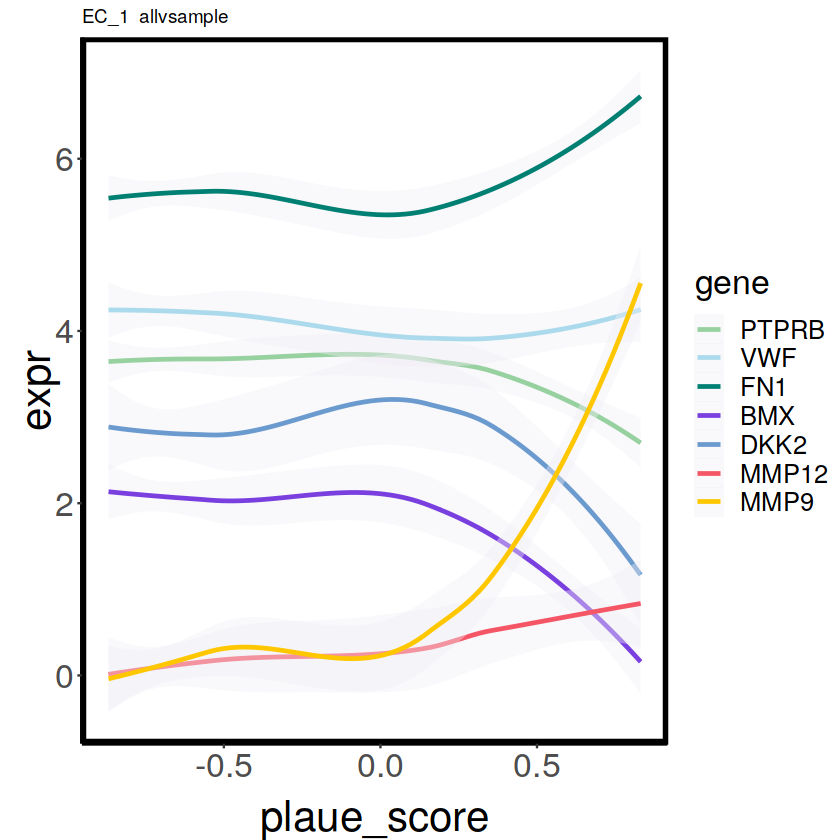

`geom_smooth()` using formula = 'y ~ x'


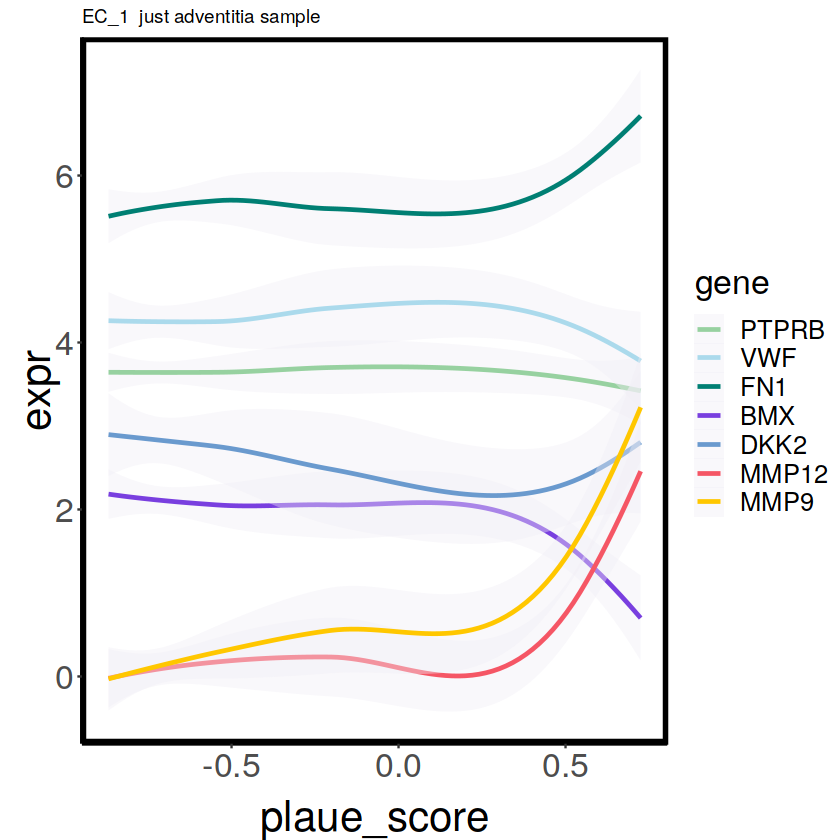

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


png 
  2

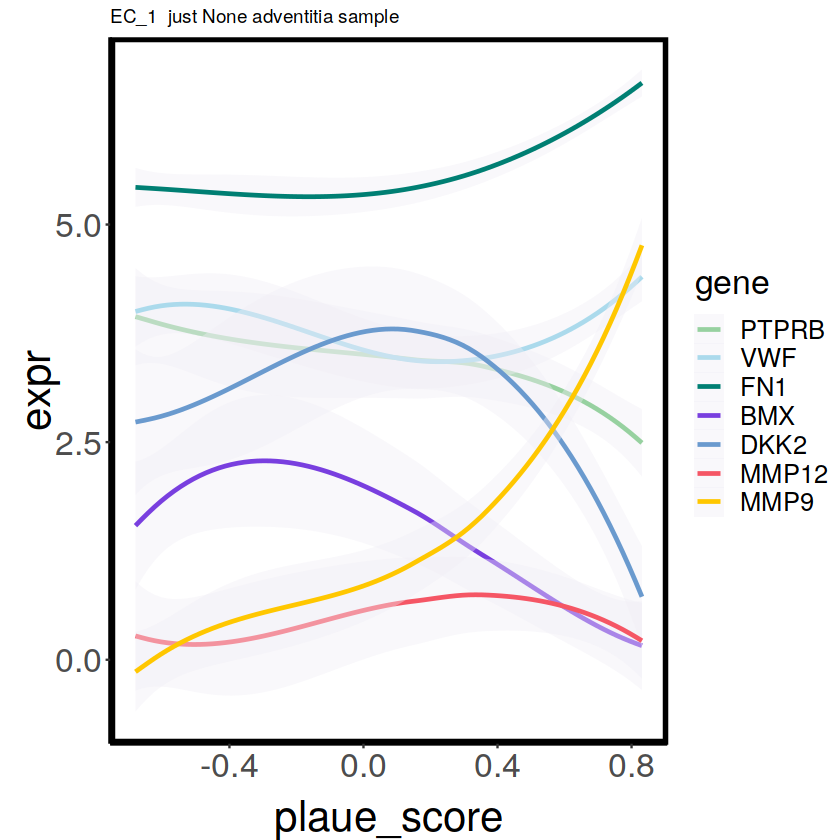

In [9]:
m1 <- subset(mer1,subset = ann2%in%c("EC_2"))
gene<-c("PTPRB","VWF","FN1","BMX","DKK2","MMP12","MMP9")
m1 <- subset(m1,select = c('score_gsva','score_ssgsea','score_addmodulescore',gene))
m2 <- melt(m1,id.vars = c('score_gsva','score_ssgsea','score_addmodulescore'))
colnames(m2)<- c('score_gsva','score_ssgsea','score_addmodulescore',"gene","exp")
p1 <- ggplot(m2,aes(x=score_gsva,y = exp,color=gene))+theme_classic ()+
scale_color_manual(values = colorRampPalette(c("#97D1A0","#ABDAEC","#007F73","#793FDF","#6A9ACE","#F55665FF","#FFC700"))(7))+geom_smooth(method = "loess",span=1,se = TRUE,level=0.9,fill='#f1eef6')+
labs(x="plaue_score",y="expr")+theme(axis.text = element_text (size = 20))+
    theme(axis.title.x=element_text(vjust=0, size=25,face = "plain"))+
    theme(axis.title.y=element_text(vjust=0, size=25,face = "plain"))+
    theme(plot.title = element_text(size = 25, face = "bold"))+
    theme(axis.line = element_line(color = "black",linewidth = 0.8))+
    theme(legend.title = element_text(size=20),
          legend.text = element_text(size=15))+
theme(panel.border = element_rect(color = "black", fill = NA, linewidth = 2))+labs(subtitle = paste0("EC_1  allvsample"))
p1
m1 <- subset(mer1,subset = ann2%in%c("EC_2")&mer1$adventitia!="none")
m1 <- subset(m1,select = c('score_gsva','score_ssgsea','score_addmodulescore',gene))
m2 <- melt(m1,id.vars = c('score_gsva','score_ssgsea','score_addmodulescore'))
colnames(m2)<- c('score_gsva','score_ssgsea','score_addmodulescore',"gene","exp")
p2 <- ggplot(m2,aes(x=score_gsva,y = exp,color=gene))+theme_classic ()+
scale_color_manual(values = colorRampPalette(c("#97D1A0","#ABDAEC","#007F73","#793FDF","#6A9ACE","#F55665FF","#FFC700"))(7))+geom_smooth(method = "loess",span=1,se = TRUE,level=0.9,fill='#f1eef6')+
labs(x="plaue_score",y="expr")+theme(axis.text = element_text (size = 20))+
    theme(axis.title.x=element_text(vjust=0, size=25,face = "plain"))+
    theme(axis.title.y=element_text(vjust=0, size=25,face = "plain"))+
    theme(plot.title = element_text(size = 25, face = "bold"))+
    theme(axis.line = element_line(color = "black",linewidth = 0.8))+
    theme(legend.title = element_text(size=20),
          legend.text = element_text(size=15))+
theme(panel.border = element_rect(color = "black", fill = NA, linewidth = 2))+labs(subtitle = paste0("EC_1  just adventitia sample"))
p2
m1 <- subset(mer1,subset = ann2%in%c("EC_2")&mer1$adventitia=="none")
m1 <- subset(m1,select = c('score_gsva','score_ssgsea','score_addmodulescore',gene))
m2 <- melt(m1,id.vars = c('score_gsva','score_ssgsea','score_addmodulescore'))
colnames(m2)<- c('score_gsva','score_ssgsea','score_addmodulescore',"gene","exp")
p3 <- ggplot(m2,aes(x=score_gsva,y = exp,color=gene))+theme_classic ()+
scale_color_manual(values = colorRampPalette(c("#97D1A0","#ABDAEC","#007F73","#793FDF","#6A9ACE","#F55665FF","#FFC700"))(7))+geom_smooth(method = "loess",span=1,se = TRUE,level=0.9,fill='#f1eef6')+
labs(x="plaue_score",y="expr")+theme(axis.text = element_text (size = 20))+
    theme(axis.title.x=element_text(vjust=0, size=25,face = "plain"))+
    theme(axis.title.y=element_text(vjust=0, size=25,face = "plain"))+
    theme(plot.title = element_text(size = 25, face = "bold"))+
    theme(axis.line = element_line(color = "black",linewidth = 0.8))+
    theme(legend.title = element_text(size=20),
          legend.text = element_text(size=15))+
theme(panel.border = element_rect(color = "black", fill = NA, linewidth = 2))+labs(subtitle = paste0("EC_1  just None adventitia sample"))
p3
pdf(paste0("vEC_gene_plaque_score.pdf"),width = 20,height = 6)
print(p1|p2|p3)
dev.off()